In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.v2 as T
from torchvision.models import
import numpy as np
import rasterio as rio
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Iterable, Union


# BYOL Basics

In this notebook, we'll discuss the basics of pre-training a model using Bootstrap Your Own Latent (BYOL). BYOL is a self-distillation approach to self-supervised learning that effectively trains a model to learn transformation-invariant representations from unlabeled data.

This is a basic, stripped down example for learning purposes. For a more complete implementation, see the [`pretrain.py` script](../pretrain.py) in this repo.

## Data setup and augmentation

### Custom `Dataset` class

To start with, we'll go ahead and define a custon `torch.utils.data.Dataset` class to load our data. This will allow us to easily use PyTorch's `DataLoader` for batching and shuffling our data during training. It also helps to abstract away the details of how data is stored and accessed. This is important for geospatial rasters because no two datasets are truly alike (e.g, bands, data types, etc.), so often this is an essential part of the process.

Found 94480 raster files.
Dataset length: 94480
Image shape: torch.Size([3, 256, 256])


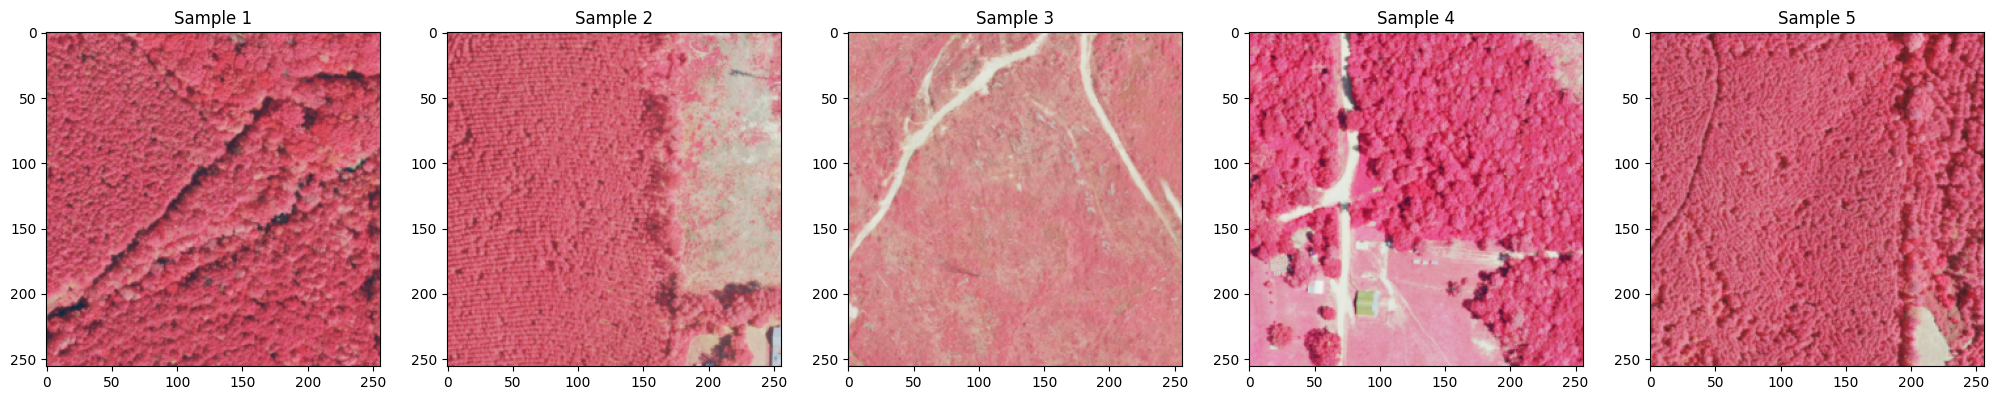

In [12]:


class BYOLDataset(torch.utils.data.Dataset):
    def __init__(self, 
            raster_paths: Iterable[Union[str, Path]], 
            transform: nn.Module = None
        ):
        self.raster_paths = raster_paths
        self.transform = transform

    def __len__(self):
        return len(self.raster_paths)

    def __getitem__(self, idx):
        raster_path = self.raster_paths[idx]
        with rio.open(raster_path) as src:
            # Read in color-infrared composites. NAIP data is stored as 
            # (R, G, B, NIR) bands, so we read in the NIR band first to get it 
            # in the right order for our model.
            img = src.read([4, 1, 2]) 
        
        # Normalize to [0, 1] - I used to do standardize to zero mean and one 
        # standard devitation (as seen in pretrain.py), but I don't anymore
        img = img.astype(np.float32) / 255.0 
        
        # now we can convert to a PyTorch tensor
        img = torch.from_numpy(img)
        
        # if we have a transform, apply it to the image
        if self.transform is not None:
            img = self.transform(img)
        
        return img


# now let's test the dataset
test_raster_paths = list(Path('/scratch/dhester/mslc_data_v2/pretrain_val').glob('*.tif')) # get all tif files
print(f'Found {len(test_raster_paths)} raster files.')

test_dataset = BYOLDataset(test_raster_paths)
print(f'Dataset length: {len(test_dataset)}')

test_img = test_dataset[0]
print(f'Image shape: {test_img.shape}') # should be (C, H, W)

fig, ax = plt.subplots(1, 5, figsize=(25, 5))
for i in range(5):
    ax[i].imshow(test_dataset[i].permute(1, 2, 0)) # permute to (H, W, C) for plotting
    ax[i].set_title(f'Sample {i+1}')

### Defining BYOL augmentations

The core idea behind BYOL is to train a model to learn to extract deep features from images that are invariant to complex transformations. PyTorch makes this very easy using `torchvision.transforms.v2` (which we have imported as `T`), which provides a convenient interface for defining complex data augmentation pipelines. 